In [1]:
from pyspark.sql import SparkSession
from pathlib import Path
import os, gc, shutil, subprocess, time

spark = (
    SparkSession.builder
    .appName("telegram-streaming-append")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.driver.memory", "8g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

BASE = Path("/kaggle/working/data")
RAW = BASE / "raw"
EXT = BASE / "ext"
FINAL = BASE / "final"

for d in [RAW, EXT, FINAL]:
    d.mkdir(parents=True, exist_ok=True)

HF_BASE = "https://huggingface.co/datasets/Tungtom2004/Telegram_politic_dataset/resolve/main"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 00:45:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
def run_cmd(cmd, name=None):
    if name:
        print(f"[START] {name}")
        start = time.time()

    result = subprocess.run(
        cmd,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print(f"[ERROR] {' '.join(cmd)}")
        print(result.stderr[:4000])
        raise subprocess.CalledProcessError(result.returncode, cmd, stderr=result.stderr)

    if name:
        print(f"[DONE] {name} ({time.time() - start:.1f}s)")


def free_gb(path="/kaggle/working"):
    total, used, free = shutil.disk_usage(path)
    return free / 1e9


def cleanup_temp(zip_path=None, extract_dir=None):
    if extract_dir and os.path.exists(extract_dir):
        shutil.rmtree(extract_dir, ignore_errors=True)
    if zip_path and os.path.exists(zip_path):
        os.remove(zip_path)
    spark.catalog.clearCache()
    gc.collect()
    print(f"[CLEANUP DONE] free disk: {free_gb():.2f} GB")

In [3]:
from pyspark.sql.functions import col, length, to_timestamp
from pathlib import Path
import zipfile


def process_one_zip_and_append(
    zip_name,
    final_output_path,
    sample_frac=0.02,
    target_languages=None,
    min_chars=20
):
    print("=" * 80)
    print(f"[INFO] processing {zip_name}")
    print(f"[INFO] free disk before: {free_gb():.2f} GB")

    if free_gb() < 4:
        raise RuntimeError(f"Not enough disk before download: {free_gb():.2f} GB")

    zip_path = RAW / zip_name
    url = f"{HF_BASE}/{zip_name}"

    # 1. download zip
    run_cmd(["wget", "-O", str(zip_path), url], name=f"download {zip_name}")
    print(f"[INFO] zip size: {zip_path.stat().st_size / 1e9:.2f} GB")

    # 2. xử lý từng file parquet trong zip để tránh full disk
    temp_root = EXT / zip_path.stem
    if temp_root.exists():
        shutil.rmtree(temp_root, ignore_errors=True)
    temp_root.mkdir(parents=True, exist_ok=True)

    processed = 0
    written = 0

    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            parquet_members = [
                m for m in zf.infolist()
                if (not m.is_dir()) and m.filename.endswith(".parquet")
            ]
            print(f"[INFO] found {len(parquet_members)} parquet files inside zip")

            if not parquet_members:
                raise ValueError(f"No parquet files found inside {zip_path}")

            for idx, member in enumerate(parquet_members, start=1):
                # giữ cấu trúc thư mục nếu có
                local_path = temp_root / member.filename
                local_path.parent.mkdir(parents=True, exist_ok=True)

                if free_gb() < 2:
                    raise RuntimeError(
                        f"Disk almost full while processing {zip_name}: {free_gb():.2f} GB left"
                    )

                zf.extract(member, path=temp_root)
                processed += 1

                try:
                    df = spark.read.parquet(str(local_path))
                    df = (
                        df.select("content", "language", "date")
                          .filter(col("content").isNotNull())
                          .filter(col("language").isNotNull())
                          .filter(col("language") != "?")
                          .filter(length(col("content")) >= min_chars)
                          .withColumn("date_ts", to_timestamp("date"))
                          .filter(col("date_ts").isNotNull())
                          .drop("date")
                    )

                    if target_languages:
                        df = df.filter(col("language").isin(target_languages))

                    if sample_frac < 1.0:
                        df = df.sample(False, sample_frac, seed=42)

                    (
                        df.write
                          .mode("append")
                          .parquet(str(final_output_path))
                    )
                    written += 1
                except Exception as e:
                    print(f"[WARN] skip {member.filename}: {e}")
                finally:
                    spark.catalog.clearCache()
                    try:
                        del df
                    except Exception:
                        pass
                    gc.collect()
                    if local_path.exists():
                        os.remove(local_path)

                    # xóa thư mục rỗng còn lại nếu có
                    parent = local_path.parent
                    while parent != temp_root and parent.exists():
                        try:
                            parent.rmdir()
                        except OSError:
                            break
                        parent = parent.parent

                if idx % 20 == 0 or idx == len(parquet_members):
                    print(
                        f"[INFO] processed {idx}/{len(parquet_members)} parquet files | "
                        f"written {written} | free disk: {free_gb():.2f} GB"
                    )
    finally:
        shutil.rmtree(temp_root, ignore_errors=True)
        if zip_path.exists():
            os.remove(zip_path)
        spark.catalog.clearCache()
        gc.collect()

    print(f"[INFO] done {zip_name} | parquet processed: {processed} | parquet written: {written}")
    print(f"[INFO] free disk after: {free_gb():.2f} GB")


In [4]:
from pyspark.sql.functions import col, length, to_timestamp
from pathlib import Path
import zipfile


def process_one_zip_and_append(
    zip_name,
    final_output_path,
    sample_frac=0.02,
    target_languages=None,
    min_chars=20
):
    print("=" * 80)
    print(f"[INFO] processing {zip_name}")
    print(f"[INFO] free disk before: {free_gb():.2f} GB")

    if free_gb() < 4:
        raise RuntimeError(f"Not enough disk before download: {free_gb():.2f} GB")

    zip_path = RAW / zip_name
    url = f"{HF_BASE}/{zip_name}"

    # 1. download zip
    run_cmd(["wget", "-O", str(zip_path), url], name=f"download {zip_name}")
    print(f"[INFO] zip size: {zip_path.stat().st_size / 1e9:.2f} GB")

    # 2. xử lý từng file parquet trong zip để tránh full disk
    temp_root = EXT / zip_path.stem
    if temp_root.exists():
        shutil.rmtree(temp_root, ignore_errors=True)
    temp_root.mkdir(parents=True, exist_ok=True)

    processed = 0
    written = 0

    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            parquet_members = [
                m for m in zf.infolist()
                if (not m.is_dir()) and m.filename.endswith(".parquet")
            ]
            print(f"[INFO] found {len(parquet_members)} parquet files inside zip")

            if not parquet_members:
                raise ValueError(f"No parquet files found inside {zip_path}")

            for idx, member in enumerate(parquet_members, start=1):
                # giữ cấu trúc thư mục nếu có
                local_path = temp_root / member.filename
                local_path.parent.mkdir(parents=True, exist_ok=True)

                if free_gb() < 2:
                    raise RuntimeError(
                        f"Disk almost full while processing {zip_name}: {free_gb():.2f} GB left"
                    )

                zf.extract(member, path=temp_root)
                processed += 1

                try:
                    df = spark.read.parquet(str(local_path))
                    df = (
                        df.select("content", "language", "date")
                          .filter(col("content").isNotNull())
                          .filter(col("language").isNotNull())
                          .filter(col("language") != "?")
                          .filter(length(col("content")) >= min_chars)
                          .withColumn("date_ts", to_timestamp("date"))
                          .filter(col("date_ts").isNotNull())
                          .drop("date")
                    )

                    if target_languages:
                        df = df.filter(col("language").isin(target_languages))

                    if sample_frac < 1.0:
                        df = df.sample(False, sample_frac, seed=42)

                    (
                        df.write
                          .mode("append")
                          .parquet(str(final_output_path))
                    )
                    written += 1
                except Exception as e:
                    print(f"[WARN] skip {member.filename}: {e}")
                finally:
                    spark.catalog.clearCache()
                    try:
                        del df
                    except Exception:
                        pass
                    gc.collect()
                    if local_path.exists():
                        os.remove(local_path)

                    # xóa thư mục rỗng còn lại nếu có
                    parent = local_path.parent
                    while parent != temp_root and parent.exists():
                        try:
                            parent.rmdir()
                        except OSError:
                            break
                        parent = parent.parent

                if idx % 20 == 0 or idx == len(parquet_members):
                    print(
                        f"[INFO] processed {idx}/{len(parquet_members)} parquet files | "
                        f"written {written} | free disk: {free_gb():.2f} GB"
                    )
    finally:
        shutil.rmtree(temp_root, ignore_errors=True)
        if zip_path.exists():
            os.remove(zip_path)
        spark.catalog.clearCache()
        gc.collect()

    print(f"[INFO] done {zip_name} | parquet processed: {processed} | parquet written: {written}")
    print(f"[INFO] free disk after: {free_gb():.2f} GB")


In [5]:
ZIP_FILES = [
    "channels_10_parquet.zip",
    "channels_11_parquet.zip",
    "channels_12_parquet.zip",
    "channels_13_parquet.zip",
    "channels_14_parquet.zip",
    "channels_15_parquet.zip",
    "channels_16_parquet.zip",
    "channels_17_parquet.zip",
    "channels_18_parquet.zip",
    "channels_19_parquet.zip",
    "channels_20_parquet.zip",
    "channels_21_parquet.zip",
    "channels_22_parquet.zip",
    "channels_23_parquet.zip",
    "channels_24_parquet.zip",
]

final_output = FINAL / "lda_input_en"

# nếu muốn chạy lại từ đầu
if final_output.exists():
    shutil.rmtree(final_output)

for z in ZIP_FILES:
    process_one_zip_and_append(
        zip_name=z,
        final_output_path=final_output,
        sample_frac=0.02,            # bắt đầu nhỏ thôi
        target_languages=["en"],     # hoặc ["en", "ru"]
        min_chars=20
    )

[INFO] processing channels_10_parquet.zip
[INFO] free disk before: 20.94 GB
[START] download channels_10_parquet.zip
[DONE] download channels_10_parquet.zip (12.0s)
[INFO] zip size: 1.93 GB
[INFO] found 810 parquet files inside zip


[INFO] processed 20/810 parquet files | written 20 | free disk: 19.01 GB


[INFO] processed 40/810 parquet files | written 40 | free disk: 19.01 GB
[INFO] processed 60/810 parquet files | written 60 | free disk: 19.01 GB
[INFO] processed 80/810 parquet files | written 80 | free disk: 19.01 GB
[INFO] processed 100/810 parquet files | written 100 | free disk: 19.01 GB
[INFO] processed 120/810 parquet files | written 120 | free disk: 19.01 GB
[INFO] processed 140/810 parquet files | written 140 | free disk: 19.01 GB


[INFO] processed 160/810 parquet files | written 160 | free disk: 19.01 GB
[INFO] processed 180/810 parquet files | written 180 | free disk: 19.01 GB
[INFO] processed 200/810 parquet files | written 200 | free disk: 19.01 GB
[INFO] processed 220/810 parquet files | written 220 | free disk: 19.01 GB
[INFO] processed 240/810 parquet files | written 240 | free disk: 19.01 GB
[INFO] processed 260/810 parquet files | written 260 | free disk: 19.01 GB
[INFO] processed 280/810 parquet files | written 280 | free disk: 19.01 GB
[INFO] processed 300/810 parquet files | written 300 | free disk: 19.01 GB
[INFO] processed 320/810 parquet files | written 320 | free disk: 19.01 GB
[INFO] processed 340/810 parquet files | written 340 | free disk: 19.01 GB


[INFO] processed 360/810 parquet files | written 360 | free disk: 19.01 GB
[INFO] processed 380/810 parquet files | written 380 | free disk: 19.01 GB


...

[INFO] processed 3740/3966 parquet files | written 3740 | free disk: 14.49 GB
[INFO] processed 3760/3966 parquet files | written 3760 | free disk: 14.49 GB
[INFO] processed 3780/3966 parquet files | written 3780 | free disk: 14.49 GB


[INFO] processed 3800/3966 parquet files | written 3800 | free disk: 14.49 GB
[INFO] processed 3820/3966 parquet files | written 3820 | free disk: 14.49 GB
[INFO] processed 3840/3966 parquet files | written 3840 | free disk: 14.49 GB
[INFO] processed 3860/3966 parquet files | written 3860 | free disk: 14.49 GB
[INFO] processed 3880/3966 parquet files | written 3880 | free disk: 14.49 GB
[INFO] processed 3900/3966 parquet files | written 3900 | free disk: 14.49 GB
[INFO] processed 3920/3966 parquet files | written 3920 | free disk: 14.49 GB
[INFO] processed 3940/3966 parquet files | written 3940 | free disk: 14.49 GB


[INFO] processed 3960/3966 parquet files | written 3960 | free disk: 14.48 GB
[INFO] processed 3966/3966 parquet files | written 3966 | free disk: 14.48 GB
[INFO] done channels_21_parquet.zip | parquet processed: 3966 | parquet written: 3966
[INFO] free disk after: 19.66 GB
[INFO] processing channels_22_parquet.zip
[INFO] free disk before: 19.66 GB
[START] download channels_22_parquet.zip
[DONE] download channels_22_parquet.zip (3.5s)
[INFO] zip size: 0.48 GB
[INFO] found 1536 parquet files inside zip
[INFO] processed 20/1536 parquet files | written 20 | free disk: 19.19 GB
[INFO] processed 40/1536 parquet files | written 40 | free disk: 19.19 GB
[INFO] processed 60/1536 parquet files | written 60 | free disk: 19.19 GB
[INFO] processed 80/1536 parquet files | written 80 | free disk: 19.19 GB
[INFO] processed 100/1536 parquet files | written 100 | free disk: 19.19 GB
[INFO] processed 120/1536 parquet files | written 120 | free disk: 19.19 GB
[INFO] processed 140/1536 parquet files | wri

[INFO] processed 20/49 parquet files | written 20 | free disk: 19.58 GB


[INFO] processed 40/49 parquet files | written 40 | free disk: 19.58 GB
[INFO] processed 49/49 parquet files | written 49 | free disk: 19.58 GB
[INFO] done channels_23_parquet.zip | parquet processed: 49 | parquet written: 49
[INFO] free disk after: 19.65 GB
[INFO] processing channels_24_parquet.zip
[INFO] free disk before: 19.65 GB
[START] download channels_24_parquet.zip
[DONE] download channels_24_parquet.zip (0.3s)
[INFO] zip size: 0.00 GB
[INFO] found 36 parquet files inside zip
[INFO] processed 20/36 parquet files | written 20 | free disk: 19.64 GB
[INFO] processed 36/36 parquet files | written 36 | free disk: 19.64 GB
[INFO] done channels_24_parquet.zip | parquet processed: 36 | parquet written: 36
[INFO] free disk after: 19.65 GB


In [6]:
!du -h --max-depth=1 /kaggle/working/data

4.0K	/kaggle/working/data/raw
1.3G	/kaggle/working/data/final
4.0K	/kaggle/working/data/ext
1.3G	/kaggle/working/data


In [7]:
df_all = spark.read.parquet(str(final_output))

print("Rows:", df_all.count())
df_all.show(5, truncate=100)

Rows: 6814332
+----------------------------------------------------------------------------------------------------+--------+-------------------+
|                                                                                             content|language|            date_ts|
+----------------------------------------------------------------------------------------------------+--------+-------------------+
|𝐒𝐓𝐀𝐑𝐓𝐄𝐃 𝐓𝐎𝐃𝐀𝐘 - 20/02/𝟮𝟬𝟮4 REEBOK 𝐑𝐄𝐆𝐈𝐒𝐓𝐑𝐀𝐓𝐈𝐎𝐍 LINK https://reebok69.c...|      en|2024-02-20 22:34:45|
|https://imcusdt.com/3de3ia 𝙈𝙞𝙣𝙞𝙢𝙪𝙢 𝘿𝙚𝙥𝙤𝙨𝙞𝙩_ 12$ 𝘿𝙖𝙞𝙡𝙮 𝙋𝙧𝙤𝙛𝙞𝙩 _ 2.58$ Ver...|      en|2024-02-20 23:32:05|
|GRATIS 5 USDT TRADIO.IA LANZAMIENTO 21/02/2024 LINK: https://tradio-app.com/app-register?ref=T000...|      en|2024-02-20 23:36:18|
|LONG-TERM TRUSTED MINER Minimum Deposit:- 15 TRX. Minimum Withdrawal:- 5 TRX Daily Income 9-36% h...|      en|2024-02-21 01:19:18|
|𝐇𝐞𝐥𝐥𝐨, @caver_31 𝐒𝐡𝐞𝐫𝐞 𝐲𝐨𝐮𝐫 𝐋𝐢𝐧𝐤𝐬 𝐎𝐧𝐞 𝐂𝐥𝐢𝐜𝐤 𝐉𝐨𝐢𝐧 𝐚𝐥𝐥 𝐆𝐫𝐨𝐮𝐩...|      en|2024-02-21 01:30:51|
+--------------------

In [8]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.clustering import LDA

df_all = spark.read.parquet(str(final_output))

tokenizer = RegexTokenizer(inputCol="content", outputCol="tokens", pattern="\\W+", toLowercase=True)
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered")
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features", vocabSize=50000, minDF=20)
lda = LDA(k=30, maxIter=20, seed=42)

pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, lda])
model = pipeline.fit(df_all)

In [9]:
cv_model = model.stages[2]
lda_model = model.stages[3]

vocab = cv_model.vocabulary
topics = lda_model.describeTopics(10).collect()

for row in topics:
    terms = [vocab[i] for i in row["termIndices"]]
    print(f"\nTopic {row['topic']}:")
    print(", ".join(terms))


Topic 0:
https, free, com, new, www, bot, join, one, us, real

Topic 1:
https, mall, vip, ic, register, 2, link, mining, bonus, 1

Topic 2:
usdt, https, 1, 2, 3, com, level, daily, vip, deposit

Topic 3:
bot, telegram, 24, hack, shill, groups, 7, dm, 1, hacking

Topic 4:
0, buy, sol, trending, price, buyer, 1, tx, spent, got

Topic 5:
https, com, shilling, seckinguvenceler, crypto, automatedshilling, shill, sol, project, like

Topic 6:
new, hongkong, moscow, crypto, community, join, telegram, transfer, ready, let

Topic 7:
https, register, daily, deposit, ic, com, usdt, level, withdrawal, minimum

Topic 8:
80, pro, amazon, starts, contact, uk, 15, wise, buy, card

Topic 9:
vip, https, register, ic, deposit, daily, 1, 2, 3, free

Topic 10:
https, com, ref, startapp, start, register, app, link, free, 000

Topic 11:
30, 10, 20, 1, 40, 50, 2, pm, https, 11

Topic 12:
https, register, daily, ic, vip, 2, withdrawal, 1, deposit, com

Topic 13:
1, 2, 0, 3, https, 4, 5, day, 8, 6

Topic 14:
ht

In [10]:
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType
from pyspark.sql.functions import udf

def argmax_topic(v):
    arr = v.toArray().tolist()
    return int(max(range(len(arr)), key=lambda i: arr[i]))

argmax_udf = udf(argmax_topic, IntegerType())

df_topic = model.transform(df_all)

df_topic = df_topic.withColumn(
    "dominant_topic",
    argmax_udf(col("topicDistribution"))
)

In [11]:
for t in range(5):
    print(f"\n=== Topic {t} ===")
    df_topic.filter(col("dominant_topic") == t) \
        .select("content") \
        .show(3, truncate=120)


=== Topic 0 ===


26/04/21 06:39:03 WARN DAGScheduler: Broadcasting large task binary with size 11.5 MiB


+------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                 content|
+------------------------------------------------------------------------------------------------------------------------+
|Free join for now direct video ¢p my channel https://t.me/+0X2niOsNGadhMmY1 Free direct video https://t.me/+6Cg9MTVwa...|
|THE BEST INVESTMENT PLATFORM IS HERE NOW I have invest with ELITE PREMIUM for more than 2 Years now and confirmed the...|
|ATM2024 A T M Register https://atm2024.org/ref/create https://atm2024.org/ref/create CAUTION!!! DO NOT USE VPN AND DO...|
+------------------------------------------------------------------------------------------------------------------------+
only showing top 3 rows

=== Topic 1 ===


26/04/21 06:41:29 WARN DAGScheduler: Broadcasting large task binary with size 11.5 MiB


+------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                 content|
+------------------------------------------------------------------------------------------------------------------------+
|hello. . Do you have a project to promote? I am a strong promoter and I have a YouTube and Telegram channel promote v...|
|Free Free Free Launched on 2-26-2024 The strongest and most famous comes back and always lasts long and lasts for sev...|
|Free Free Free Launched on 2-26-2024 The strongest and most famous comes back and always lasts long and lasts for sev...|
+------------------------------------------------------------------------------------------------------------------------+
only showing top 3 rows

=== Topic 2 ===


...

+------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                 content|
+------------------------------------------------------------------------------------------------------------------------+
|NEW PLATFORM : DOUBLE-FLOW (18/2/2024) https://double-flow.cc/?ref=investin21 https://double-flow.cc/?ref=investin21 ...|
|Start: 20.02.2024 Withdraw fee 0 Minimum invest 20$ Minimum withdraw 3$ Investment Plan Vip1-Invest 20$- Daily Earnin...|
|𝗗𝗲𝗽𝗼𝘀𝗶𝘁 $, 𝗮𝗻𝗱 𝗱𝗮𝗶𝗹𝘆 $ https://morrisons-shop.com/cFh6j9 https://morrisons-shop.com/cFh6j9 https://mor...|
+------------------------------------------------------------------------------------------------------------------------+
only showing top 3 rows

=== Topic 3 ===


26/04/21 06:46:01 WARN DAGScheduler: Broadcasting large task binary with size 11.5 MiB


+------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                 content|
+------------------------------------------------------------------------------------------------------------------------+
|PLATAFORMA DE APUESTAS CON SEÑALES OFICIALES Y UN BOT 1 MINUTO https://m.bousdt.org/#/?sc=351565663 DEPÓSITO MÍN $10 ...|
|                                                                                             I have pinned this message.|
|I'm available for all instructional and hacking services. This are my services Social media/ Gmail Hacking WhatsApp A...|
+------------------------------------------------------------------------------------------------------------------------+
only showing top 3 rows

=== Topic 4 ===


26/04/21 06:48:20 WARN DAGScheduler: Broadcasting large task binary with size 11.5 MiB


+------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                 content|
+------------------------------------------------------------------------------------------------------------------------+
|چک XCrypto برای 144178.3532 RUBLE (56,073.03 تومان) داخل چک : 12500 فعالسازی به مبلغ 11.534268256 RUBLE (4.49 تومان) ...|
|                                                                                                  Cum on Baby i am Model|
|Simplify Your Shipping with SimpleShip Ever felt like shipping costs are just too high? Say goodbye to expensive labe...|
+------------------------------------------------------------------------------------------------------------------------+
only showing top 3 rows


In [12]:
topic_counts = df_topic.groupBy("dominant_topic").count().toPandas()

26/04/21 06:50:38 WARN DAGScheduler: Broadcasting large task binary with size 11.5 MiB
26/04/21 07:25:34 WARN DAGScheduler: Broadcasting large task binary with size 11.5 MiB


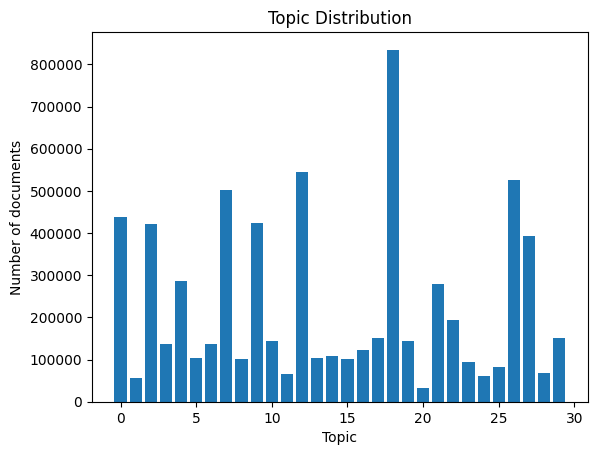

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(topic_counts["dominant_topic"], topic_counts["count"])
plt.xlabel("Topic")
plt.ylabel("Number of documents")
plt.title("Topic Distribution")
plt.show()

In [14]:
topics = lda_model.describeTopics(10).collect()

for row in topics[:5]:
    topic_id = row["topic"]
    terms = [vocab[i] for i in row["termIndices"]]
    weights = row["termWeights"]

    print(f"\nTopic {topic_id}")
    for t, w in zip(terms, weights):
        print(f"{t}: {w:.4f}")


Topic 0
https: 0.0110
free: 0.0098
com: 0.0057
new: 0.0042
www: 0.0038
bot: 0.0037
join: 0.0035
one: 0.0035
us: 0.0033
real: 0.0031

Topic 1
https: 0.0351
mall: 0.0319
vip: 0.0238
ic: 0.0231
register: 0.0179
2: 0.0162
link: 0.0122
mining: 0.0116
bonus: 0.0110
1: 0.0103

Topic 2
usdt: 0.0541
https: 0.0467
1: 0.0273
2: 0.0269
3: 0.0263
com: 0.0238
level: 0.0227
daily: 0.0171
vip: 0.0167
deposit: 0.0164

Topic 3
bot: 0.0235
telegram: 0.0186
24: 0.0140
hack: 0.0138
shill: 0.0136
groups: 0.0133
7: 0.0117
dm: 0.0103
1: 0.0102
hacking: 0.0102

Topic 4
0: 0.0557
buy: 0.0343
sol: 0.0298
trending: 0.0262
price: 0.0209
buyer: 0.0194
1: 0.0192
tx: 0.0179
spent: 0.0158
got: 0.0156


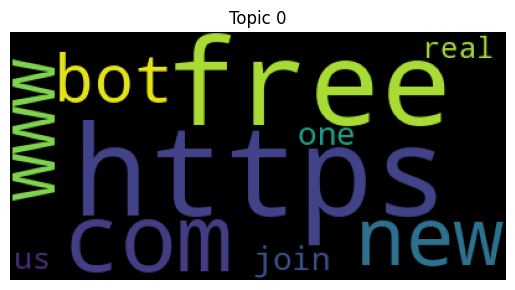

In [15]:
from wordcloud import WordCloud

row = topics[0]
terms = [vocab[i] for i in row["termIndices"]]
weights = row["termWeights"]

freq = dict(zip(terms, weights))

wc = WordCloud().generate_from_frequencies(freq)

plt.figure()
plt.imshow(wc)
plt.axis("off")
plt.title("Topic 0")
plt.show()